# Etna Cause–Trigger Analysis

This notebook applies the current Cause–Trigger implementation to the fixed Etna case-study interval around the Wenchuan teleseismic arrival.

The analysis is organized to avoid post-hoc hyperparameter selection:

- the case interval, effect, minimum interval lengths, and maximum lag are fixed before fitting;
- VAR-AIC and VAR-BIC are lag references only;
- the primary result is stability across lags and causal-discovery backends;
- PCMCI+ contemporaneous-trigger testing is retained as an explicitly labelled extension;
- the known Wenchuan time is contextual and does not determine the algorithmic split.

Two aligned standardized frames are used:

- `X_model`: case-standardized data for causal discovery, coefficient estimation, \(V\), and moderation;
- `X_mean`: pre-case-reference-standardized data for the split and mean-comparison steps.

Accepted pairs are displayed as **Cause | Trigger**. For Etna, the target effect is anomalous local catalogue seismicity. The exported audit files preserve every backend–lag result and every accepted or rejected moderation test, while the notebook displays only the stability summaries needed for interpretation.


## Imports and configuration


In [1]:
from pathlib import Path
import sys

import pandas as pd

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cause_trigger_cases import ETNA_CASE
from cause_trigger_reporting import (
    backend_stability_summary,
    delayed_lag_correlation,
    export_audit_csvs,
    pair_stability_summary,
    plot_effect_with_split,
    reference_moderation_table,
    run_complete_grid,
    show_table,
)
from cause_trigger_workflow import (
    COMPACT_RUN_SPECS,
    WorkflowConfig,
    case_study_interval,
    load_model_frame,
    pre_case_reference_interval,
    prepare_case_frames,
    reference_parameter_table,
    run_one,
    split_diagnostics,
)

CASE = ETNA_CASE
EFFECT = CASE.effect
MODEL_COLUMNS = CASE.model_columns
VARIABLE_LABELS = CASE.variable_labels

DATA_PATH = PROJECT_ROOT / "data" / "etna" / "etna_dataset.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

SAVE_RESULTS = True
SHOW_FULL_GRID = False
SHOW_SCALING_REPORT = False

EVENT_TIME = pd.Timestamp("2008-05-12 06:28:00", tz="UTC")

CASE_PRE_DAYS = 3
CASE_POST_HOURS = 72
MIN_I1_LENGTH = 48
MIN_I2_LENGTH = 72

MAX_LAGS = 12
LAG_GRID = tuple(range(1, MAX_LAGS + 1))

REFERENCE_DAYS = 14
REFERENCE_MIN_COVERAGE = 0.90

ALPHA = 0.05
PCMCI_PC_ALPHA = 0.05
PCMCI_ALPHA_LEVEL = 0.05
PCMCI_FDR_METHOD = "fdr_bh"
COND_IND_TEST = "robust_parcorr"


### Fixed data and split

The primary interval contains **3 days before** and 72 hours after the Wenchuan arrival. Both \(I_1\) and \(I_2\) must contain at least 48 hourly observations. Lags from 1 to 12 hours are evaluated.

The CSV remains unstandardized; transformations and scaling are fitted within this workflow. The known Wenchuan time is plotted for context but does not constrain the split.


Item,Value
Case interval,2008-05-09 06:00:00+00:00 to 2008-05-15 05:00:00+00:00 (144 h)
Reference coverage,336/336 h (100.0%)
Wenchuan arrival,2008-05-12 06:28:00+00:00
Effect maximum,2008-05-13 13:00:00+00:00 (1 days 06:32:00)
Automatic split,"2008-05-12 06:00:00+00:00; I1=72 h, I2=72 h"
Split status,Boundary solution; -1 days +23:32:00 after Wenchuan
VAR lag references,AIC=12 h; BIC=1 h


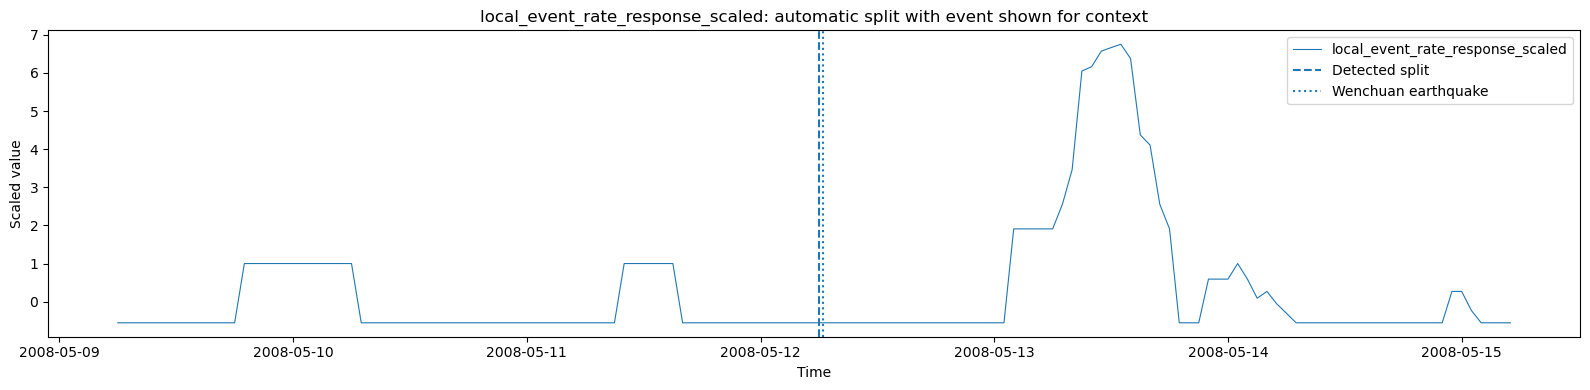

(<Figure size 1600x400 with 1 Axes>,
 <Axes: title={'center': 'local_event_rate_response_scaled: automatic split with event shown for context'}, xlabel='Time', ylabel='Scaled value'>,
 [WindowsPath('c:/Users/cescedes/Desktop/Distinguishing Causes and Triggers in Volcanic and Seismic Processes/figures/etna_effect_split.pdf'),
  WindowsPath('c:/Users/cescedes/Desktop/Distinguishing Causes and Triggers in Volcanic and Seismic Processes/figures/etna_effect_split.png')])

In [2]:
X_full_raw = load_model_frame(
    DATA_PATH,
    include_columns=MODEL_COLUMNS,
    require_complete=False,
    index_name=CASE.index_name,
)

X_case_raw = case_study_interval(
    X_full_raw,
    EVENT_TIME,
    pre_days=CASE_PRE_DAYS,
    post_hours=CASE_POST_HOURS,
)

reference_raw = pre_case_reference_interval(
    X_full_raw,
    case_start=X_case_raw.index.min(),
    reference_days=REFERENCE_DAYS,
    min_coverage=REFERENCE_MIN_COVERAGE,
    case_name=CASE.name,
)

X_model, X_mean, scaling_report = prepare_case_frames(
    X_case_raw,
    reference_raw,
    case=CASE,
)

reference_parameters = reference_parameter_table(
    X_model,
    EFFECT,
    fallback_lag=1,
)
REFERENCE_LAGS = tuple(
    int(value)
    for value in sorted(
        reference_parameters["selected_lag"].astype(int).unique()
    )
)

workflow = WorkflowConfig(
    effect=EFFECT,
    alpha=ALPHA,
    selected_lag=REFERENCE_LAGS[0],
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
    distribution="gaussian",
    refit_alpha=1.0,
    refit_cv=True,
    refit_cv_folds=3,
    pcmci_pc_alpha=PCMCI_PC_ALPHA,
    pcmci_alpha_level=PCMCI_ALPHA_LEVEL,
    pcmci_fdr_method=PCMCI_FDR_METHOD,
    pcmci_cond_ind_test=COND_IND_TEST,
    pcmci_plus_use_contemporaneous_triggers=False,
)

split_row = split_diagnostics(
    X_mean,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
)

lag_reference_text = "; ".join(
    f"{row.criterion}={int(row.selected_lag)} h"
    for row in reference_parameters.itertuples()
)

effect_peak = X_case_raw[CASE.raw_effect].idxmax()

design_summary = pd.DataFrame([
    {
        "Item": "Case interval",
        "Value": (
            f"{X_case_raw.index.min()} to {X_case_raw.index.max()} "
            f"({len(X_case_raw)} h)"
        ),
    },
    {
        "Item": "Reference coverage",
        "Value": (
            f"{len(reference_raw)}/"
            f"{reference_raw.attrs['expected_rows']} h "
            f"({reference_raw.attrs['coverage']:.1%})"
        ),
    },

    {"Item": "Wenchuan arrival", "Value": str(EVENT_TIME)},
    {
        "Item": "Effect maximum",
        "Value": f"{effect_peak} ({effect_peak - EVENT_TIME})",
    },

    {
        "Item": "Automatic split",
        "Value": (
            f"{split_row['split_time']}; "
            f"I1={split_row['I1_length']} h, "
            f"I2={split_row['I2_length']} h"
        ),
    },
    {
        "Item": "Split status",
        "Value": (
            "Boundary solution; "
            f"{split_row['distance_to_event']} after Wenchuan"
),
    },
    {"Item": "VAR lag references", "Value": lag_reference_text},
])

show_table(design_summary, "Fixed design and timing")

if SHOW_SCALING_REPORT:
    show_table(
        scaling_report.reset_index(names="Variable"),
        "Transformation and scaling audit",
    )

plot_effect_with_split(
    X_mean,
    EFFECT,
    split_row,
    event_time=EVENT_TIME,
    event_label="Wenchuan earthquake",
    title=None,
    filename="etna_effect_split",
    save_dir=FIGURES_DIR,
    formats=("pdf", "png"),
)


## Primary backend-by-lag stability analysis

Each backend is run **once at every lag from 1 to 12 hours** under the same preprocessing, split rule, and significance level:

- **HMML**: paper-compatible primary causal-discovery backend;
- **PCMCI**: lagged causal discovery;
- **PCMCI+ \(tau=0\) extension**: lagged discovery plus eligible directed contemporaneous links as trigger candidates.

The notebook displays compact stability summaries. The complete backend–lag grid and every moderation diagnostic are saved to CSV, including no-signal runs and rejected candidate pairs.


In [3]:
lag_grid, all_diagnostics = run_complete_grid(
    X_model,
    X_mean,
    workflow,
    run_one=run_one,
    run_specs=COMPACT_RUN_SPECS,
    lags=LAG_GRID,
    cond_ind_test=COND_IND_TEST,
)

errors = lag_grid.loc[lag_grid["error"].notna()].copy()
backend_summary = backend_stability_summary(
    lag_grid,
    lag_count=len(LAG_GRID),
)
pair_summary = pair_stability_summary(
    lag_grid,
    lag_count=len(LAG_GRID),
    variable_labels=VARIABLE_LABELS,
)

show_table(backend_summary, "Backend stability")
show_table(pair_summary, "Accepted cause–trigger pairs across lags")

if not pair_summary.empty:
    top = pair_summary.iloc[0]
    print(
        "Most recurrent accepted pair: "
        f"{top['Cause']} | {top['Trigger']} "
        f"at {top['Lag support']} lags."
    )

if not errors.empty:
    show_table(
        errors[["run", "backend", "lag", "error"]],
        "Execution errors",
    )

if SHOW_FULL_GRID:
    show_table(
        lag_grid.drop(columns="error"),
        "Complete backend-by-lag grid",
    )


c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:898: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(resid / self.family.variance(mu)) / self.df_resid
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:898: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(resid / self.family.variance(mu)) / self.df_resid
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\ces

Backend,Successful runs,Post-split parents,Trigger candidates,Accepted-pair lags,τ=0-link lags,Result
HMML,12/12,7/12,7/12,6/12,0/12,Accepted pair(s) at 6 lag(s)
PCMCI,12/12,9/12,9/12,4/12,0/12,Accepted pair(s) at 4 lag(s)
PCMCI+ τ=0,12/12,7/12,7/12,5/12,2/12,Accepted pair(s) at 5 lag(s)


Backend,Cause,Trigger,Accepted lags,Lag support,Longest adjacent run
HMML,Past local seismicity,Teleseismic RMS,"[6, 7, 8, 9, 10]",5/12,5
PCMCI,Soil CO₂,Teleseismic RMS,"[6, 7, 8, 10]",4/12,3
PCMCI,Teleseismic RMS,Soil CO₂,"[6, 7, 8, 10]",4/12,3
PCMCI+ τ=0,Soil CO₂,Teleseismic RMS,"[4, 5, 11]",3/12,2
PCMCI+ τ=0,Teleseismic RMS,Soil CO₂,"[4, 5, 11]",3/12,2
PCMCI+ τ=0,Soil CO₂,Past local seismicity,"[6, 10]",2/12,1
HMML,Soil CO₂,Past local seismicity,[11],1/12,1
HMML,Soil CO₂,Teleseismic RMS,[11],1/12,1
HMML,Past local seismicity,Soil CO₂,[11],1/12,1


Most recurrent accepted pair: Past local seismicity | Teleseismic RMS at 5/12 lags.


## VAR reference-lag check

In [4]:
reference_display = reference_moderation_table(
    all_diagnostics,
    reference_parameters,
    variable_labels=VARIABLE_LABELS,
)

if reference_display.empty:
    print(
        "No cause–trigger pair passed moderation at the "
        f"AIC/BIC reference lags {REFERENCE_LAGS}."
    )
else:
    show_table(
        reference_display,
        "Accepted pairs at VAR reference lags",
    )


No cause–trigger pair passed moderation at the AIC/BIC reference lags (1, 12).


## Etna-specific delayed-lag diagnostic

The catalogue-response episode begins well after the main Wenchuan pulse. This descriptive scan evaluates the correlation between the transformed teleseismic proxy at \(t-tau\) and the effect at \(t\) over the complete case interval for delays up to 30 hours.

It does **not** replace the Cause–Trigger analysis, estimate a causal delay, or justify selecting the lag with the largest correlation.


In [5]:
MAX_DELAY_HOURS = 30

delayed_lag_scan = delayed_lag_correlation(
    X_model,
    effect=EFFECT,
    predictor="teleseismic_scaled",
    max_lag=MAX_DELAY_HOURS,
)

top_delays = (
    delayed_lag_scan
    .assign(abs_correlation=lambda frame: frame["correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
    .drop(columns="abs_correlation")
    .head(10)
)

show_table(
    top_delays.rename(columns={
        "lag_hours": "Delay (h)",
        "correlation": "Correlation",
        "n_aligned": "Aligned rows",
    }),
    "Largest absolute full-case teleseismic–effect correlations",
)


Delay (h),Correlation,Aligned rows
28,0.489043,116
29,0.486995,115
27,0.477667,117
30,0.464153,114
26,0.413561,118
1,0.378477,143
0,0.369868,144
2,0.351258,142
25,0.315623,119
3,0.310341,141


Delay (h),Correlation,Aligned rows
28,0.489043,116
29,0.486995,115
27,0.477667,117
30,0.464153,114
26,0.413561,118
1,0.378477,143
0,0.369868,144
2,0.351258,142
25,0.315623,119
3,0.310341,141


## Saved audit outputs

The notebook writes exactly three CSV files:

1. **All runs** — one row for every backend × lag combination, including empty results and errors.
2. **Moderation diagnostics** — every tested cause–trigger pair, accepted or rejected, with the complete test statistics and reason.
3. **Analysis summary** — design, split, lag references, backend stability, pair stability summary.


In [6]:
if SAVE_RESULTS:
    saved_files = export_audit_csvs(
        results_dir=RESULTS_DIR,
        case_prefix="etna",
        lag_grid=lag_grid,
        diagnostics=all_diagnostics,
        design=design_summary,
        lag_references=reference_parameters,
        backend_summary=backend_summary,
        pair_summary=pair_summary,
        variable_labels=VARIABLE_LABELS,
        delayed_scan=delayed_lag_scan,
    )
    show_table(saved_files, "Saved result files")


File,Contents,Rows
etna_cause_trigger_all_runs.csv,"Every backend × lag run, including empty results, candidate sets, accepted pairs, effective sample size, stop reasons, and errors.",36
etna_cause_trigger_moderation_diagnostics.csv,"Every evaluated cause–trigger combination, accepted or rejected, with complete test statistics and reasons.",42
etna_cause_trigger_summary.csv,"Design, split, lag references, backend stability, pair stability, plus the complete descriptive delayed-lag scan.",53
